# 04 · Estructura del catálogo sin etiquetas

El módulo M4 del diplomado declara dos cosas: **clustering de perfiles de demanda** como
feature de arranque en frío, y **detección de anomalías** con Isolation Forest.

## Qué hay implementado y qué no

| Pieza | Estado | Dónde |
|---|---|---|
| PCA del catálogo de productos | **implementado** | `src/blindside/unsupervised/embeddings.py` |
| K-Means / DBSCAN de perfiles | pendiente | — |
| Isolation Forest de anomalías | pendiente | — |

Este notebook cubre lo primero y **declara** los dos huecos en vez de simularlos. La PCA no se
escribió como ejercicio de no supervisado: se escribió porque la interfaz tiene una pantalla de
mapa de productos y ese mapa necesitaba coordenadas que signifiquen algo.

Es una diferencia que vale marcar. Una proyección que existe porque una pantalla la consume
tiene un criterio de utilidad; una que existe para llenar un módulo, no.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from blindside import config as cfg
from blindside.data import loaders
from blindside.data import schema as S
from blindside.unsupervised import embeddings as emb

pd.set_option("display.width", 120)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25})

panel = loaders.load_demand()
print(f"panel: {panel[S.PRODUCT_ID].nunique()} productos · {panel[S.SERIES_ID].nunique():,} series")

panel: 309 productos · 3,066 series


## 1 · Las seis features por producto

Una fila por producto, agregando sus series de todas las tiendas. Las seis describen **cómo se
comporta** el producto, no cuánto vende: nivel, variabilidad, intermitencia, quiebre y
estacionalidad.

La amplitud semanal está normalizada por el nivel a propósito — sin eso sería otra medida de
tamaño y la primera componente sería trivialmente «producto grande contra producto chico».

In [2]:
tabla = emb.product_features(panel, target=S.DEMAND_LATENT)
print(f"features usadas por la proyección: {emb.FEATURES}")
display(tabla.describe().T.round(4))

features usadas por la proyección: ('demanda_media', 'coef_variacion', 'tasa_quiebre', 'tasa_ceros', 'amplitud_semanal', 'horas_quiebre')


,count,mean,std,min,25%,50%,75%,max
demanda_media,309.0,0.9504,0.7251,0.4453,0.5817,0.6752,1.0239,5.8218
coef_variacion,309.0,0.7017,0.2319,0.3302,0.5861,0.6430,0.7653,2.1669
tasa_quiebre,309.0,0.4112,0.1453,0.1237,0.3282,0.3891,0.4705,0.9897
tasa_ceros,309.0,0.0408,0.0631,0.0000,0.0091,0.0199,0.0412,0.5258
amplitud_semanal,309.0,0.1969,0.1051,0.0348,0.1370,0.1753,0.2228,1.1280
horas_quiebre,309.0,2.9085,1.0494,1.5670,2.2842,2.6326,3.1927,8.5626
n_series,309.0,9.9223,10.4101,1.0000,2.0000,5.0000,16.0000,36.0000


### Por qué hay que estandarizar antes de proyectar

Las seis están en unidades incomparables: una demanda media contra una tasa entre 0 y 1. Sin
estandarizar, la primera componente sería simplemente la variable de mayor escala. La celda de
abajo lo muestra con los desvíos crudos.

In [3]:
desvios = tabla[list(emb.FEATURES)].std().sort_values(ascending=False)
display(desvios.round(4).to_frame("desvío crudo"))
print(f"razón entre el mayor y el menor desvío: {desvios.iloc[0] / desvios.iloc[-1]:.0f}×")
print("\nSin estandarizar, la componente 1 sería casi exactamente la primera variable.")

,desvío crudo
horas_quiebre,1.0494
demanda_media,0.7251
coef_variacion,0.2319
tasa_quiebre,0.1453
amplitud_semanal,0.1051
tasa_ceros,0.0631


razón entre el mayor y el menor desvío: 17×

Sin estandarizar, la componente 1 sería casi exactamente la primera variable.


## 2 · La proyección

`project_products` estandariza y proyecta a dos componentes. Devuelve los puntos y la **varianza
explicada**, que es la cifra que dice si el dibujo se puede leer o no.

In [4]:
puntos, varianza = emb.project_products(panel, target=S.DEMAND_LATENT)
print(f"productos proyectados: {len(puntos)}")
print(f"varianza explicada   : PC1 {varianza[0]:.1%} · PC2 {varianza[1]:.1%} · total {sum(varianza):.1%}")
display(puntos.head(8).round(4))

productos proyectados: 309
varianza explicada   : PC1 37.5% · PC2 29.9% · total 67.4%


,product_id,x,y,rotation_band,demanda_media,tasa_quiebre,n_series
0,2,0.2466,-0.2819,baja,0.5621,0.4278,4
1,4,1.9646,2.0325,alta,3.9786,0.4771,32
2,6,-1.2690,0.7093,media,0.9994,0.5561,36
3,7,-0.4210,-0.2118,baja,0.5807,0.4186,5
4,9,-0.6360,-1.4014,baja,0.6412,0.3093,1
5,11,-0.2409,-1.1826,media,0.7799,0.3039,19
6,12,-0.0627,-0.5268,baja,0.5882,0.3711,15
7,13,2.0409,-1.5774,media,0.8621,0.1340,1


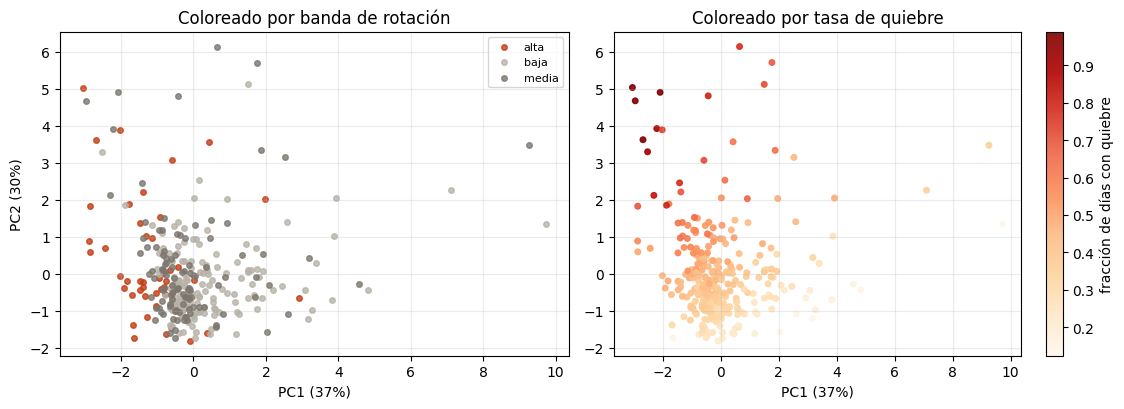

In [5]:
colores = {"baja": "#B8B2A8", "media": "#7C766E", "alta": "#C23D14"}
fig, ejes = plt.subplots(1, 2, figsize=(11.5, 4.2))

for banda, grupo in puntos.groupby("rotation_band"):
    ejes[0].scatter(
        grupo["x"], grupo["y"], s=16, alpha=0.8, label=banda, color=colores.get(banda, "#5A5550")
    )
ejes[0].set_title("Coloreado por banda de rotación")
ejes[0].set_xlabel(f"PC1 ({varianza[0]:.0%})")
ejes[0].set_ylabel(f"PC2 ({varianza[1]:.0%})")
ejes[0].legend(fontsize=8)

sc = ejes[1].scatter(
    puntos["x"], puntos["y"], c=puntos["tasa_quiebre"], s=16, cmap="OrRd", alpha=0.9
)
ejes[1].set_title("Coloreado por tasa de quiebre")
ejes[1].set_xlabel(f"PC1 ({varianza[0]:.0%})")
fig.colorbar(sc, ax=ejes[1], label="fracción de días con quiebre")
fig.tight_layout()
plt.show()

### Cómo leer esto sin engañarse

Dos advertencias, y la segunda es la que suele faltar en este tipo de gráfico.

**1 · Las bandas de rotación son cortes por cuantil.** Que se separen en el mapa no es un
descubrimiento: la banda se define a partir de la demanda media, y la demanda media es una de
las seis features proyectadas. Sería raro que **no** se separaran. El color de banda está para
orientar la lectura, no como validación.

**2 · Con ~67 % de varianza explicada, un tercio de la estructura no está en el dibujo.** Dos
productos que caen cerca pueden diferir en lo que quedó afuera. Por eso el mapa de la interfaz
sirve para explorar y no para decidir.

La celda de abajo mide cuánto aporta cada feature original a cada componente, que es lo que
convierte el eje en algo interpretable.

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(tabla[list(emb.FEATURES)].to_numpy(dtype="float64"))
pca = PCA(n_components=2, random_state=0).fit(X)
cargas = pd.DataFrame(pca.components_.T, index=list(emb.FEATURES), columns=["PC1", "PC2"])
display(cargas.round(3))

print("PC1 está dominada por:", cargas["PC1"].abs().idxmax())
print("PC2 está dominada por:", cargas["PC2"].abs().idxmax())

,PC1,PC2
demanda_media,-0.236,0.091
coef_variacion,0.596,0.209
tasa_quiebre,-0.325,0.618
tasa_ceros,0.507,0.195
amplitud_semanal,0.450,0.236
horas_quiebre,-0.156,0.688


PC1 está dominada por: coef_variacion
PC2 está dominada por: horas_quiebre


## 3 · ¿Cuántas componentes harían falta de verdad?

Se usan dos porque el destino es una pantalla. La curva de varianza acumulada dice cuánto se
está dejando afuera por esa decisión de presentación.

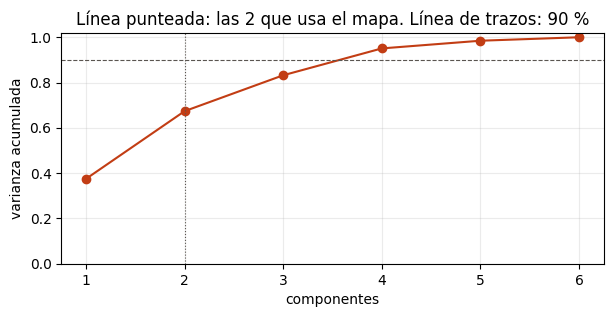

varianza con 2 componentes : 67.4%
componentes para el 90 %   : 4


In [7]:
completo = PCA(n_components=len(emb.FEATURES), random_state=0).fit(X)
acumulada = np.cumsum(completo.explained_variance_ratio_)

fig, eje = plt.subplots(figsize=(7, 3))
eje.plot(range(1, len(acumulada) + 1), acumulada, marker="o", color="#C23D14")
eje.axhline(0.9, color="#5A5550", ls="--", lw=0.8)
eje.axvline(2, color="#5A5550", ls=":", lw=0.8)
eje.set_xlabel("componentes")
eje.set_ylabel("varianza acumulada")
eje.set_title("Línea punteada: las 2 que usa el mapa. Línea de trazos: 90 %")
eje.set_ylim(0, 1.02)
plt.show()

necesarias = int(np.searchsorted(acumulada, 0.9) + 1)
print(f"varianza con 2 componentes : {acumulada[1]:.1%}")
print(f"componentes para el 90 %   : {necesarias}")

## 4 · Los dos huecos de M4, ahora cerrados y medidos

Esta seccion declaraba las dos piezas de M4 como no implementadas. Ya estan, en
`blindside.unsupervised.clustering` y `blindside.unsupervised.anomalies`, y lo que sigue
es lo que salio de medirlas — incluido un resultado negativo que se reporta.

**Clustering de perfiles: implementado, y su feature NO entra al modelo servido.**
`DemandProfileClusters` agrupa por **forma** de la serie (siete features normalizadas por el
nivel: coeficiente de variacion, tasa y racha de ceros, amplitud semanal, pico relativo,
autocorrelacion al rezago 7, tasa de quiebre). Se ajusta **una vez por origen**, porque un
cluster calculado sobre la serie completa mira el futuro.

Los grupos son interpretables y estables — indice de Rand ajustado **0,832** entre dos origenes
separados por una semana — pero la silueta es **0,21**, que dice que estan pegados: el espacio de
formas de demanda es mas un continuo que un conjunto de nichos. DBSCAN lo confirma desde el otro
lado, dejando el 19,6 % de las series en la clase de ruido.

Y el efecto de la feature sobre el modelo, medido pareado sobre 600 series y tres origenes, es
**+0,28 % de MASE medio con oscilaciones de ±11 puntos entre origenes**. La dispersion aplasta al
efecto. Con un solo fold la conclusion habria sido la contraria: el origen del 25 de junio dice
que empeora 11 % y el del 11 dice que mejora 9,8 %.

**El arranque en frio, que es su proposito declarado, no se puede medir en este panel.** Las 3066
series tienen exactamente 97 dias, ninguna tiene menos de 21, y ninguna empieza a vender despues
del dia 16. FreshRetailNet entrega ventanas completas por construccion, asi que la condicion que
la feature ataca no ocurre nunca. Se puede mostrar el mecanismo; el beneficio, no. Y una feature
cuyo beneficio no se puede medir no entra al artefacto que se sirve. Detalle en D23.

**Deteccion de anomalias: implementada, y apunta a lo que NO esta anotado.** La distincion que
esta seccion ya hacia resulto ser el criterio correcto. Como el quiebre viene etiquetado hora por
hora, la utilidad se mide por lo que el detector encuentra **fuera** de esa etiqueta. Sobre
236.082 ventanas de 14 dias, marcando el 1 % mas raro: de las 2.361 marcadas, el **49,9 %** ya
eran quiebre — contra una tasa base del **42,4 %** en el panel. Siete puntos sobre el azar en esa
dimension, o sea que **no** es un redescubridor de quiebres. Su aporte son las **1.182** ventanas
raras que ninguna columna marcaba, que es el material que contamina un entrenamiento en silencio.

`residual_anomalies` cubre lo otro que esta seccion pedia: detectar sobre el residuo del
pronostico, que encuentra lo que el modelo **no vio venir** — distinto de lo que es raro en si
mismo, porque un pico de fin de semana es raro en la serie y no es noticia si el modelo lo
esperaba.

In [8]:
# Lo que el clustering recibiría, ya disponible: una fila por producto y seis columnas
# numéricas, estandarizables. El hueco es de modelado, no de datos.
print(f"matriz lista para clustering: {tabla.shape[0]} productos × {len(emb.FEATURES)} features")
print(f"sin nulos: {not tabla[list(emb.FEATURES)].isna().any().any()}")

# Los tipos de anomalía ya están declarados en `api/schemas.py` como `AnomalyKind`:
# load_error, stockout, residual_spike, level_shift. No se importan acá a propósito:
# `api` no es un paquete instalable y traerlo exigiría manipular `sys.path`, que es
# exactamente lo que el src-layout del proyecto evita (D3).
print("\nEl contrato de anomalías existe en api/schemas.py; el detector es el que falta.")

matriz lista para clustering: 309 productos × 6 features
sin nulos: True

El contrato de anomalías existe en api/schemas.py; el detector es el que falta.


## Lo que sale de aca

- La proyeccion es **medida**, no un dibujo: 6 features estandarizadas, PCA, varianza reportada.
- Con ~67 % de varianza en dos componentes, el mapa sirve para explorar y no para decidir, y la
  interfaz lo dice.
- Que las bandas de rotacion se separen en el mapa es tautologico, porque la banda se deriva de
  una de las features proyectadas. Esta como orientacion visual.
- **M4 esta completo**: PCA, clustering con K-Means y DBSCAN, e Isolation Forest sobre ventanas.
- **Y el resultado de su feature es negativo, lo que tambien se reporta.** El cluster no mejora
  al modelo de forma medible (+0,28 % con ±11 de dispersion) y su proposito declarado —el
  arranque en frio— no es medible en un panel donde ninguna serie arranca en frio. Publicar eso
  cuesta mas que publicar una mejora, y es lo que hace que el resto de los numeros se puedan
  creer.

**Sigue:** `05_decision_conformal.ipynb` — del pronostico a la cantidad a pedir.